# Train YOLOv11 on Synthetic MNIST Canvases

## Import Libraries

In [1]:
from ultralytics import YOLO
import os

### Define Dataset Paths

In [2]:
# Base dataset folder
data_dir = "../data/mnist_yolo_training"  # change to your path

# Only train folder has annotations
train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

# COCO JSON for train only
train_json = os.path.join(train_dir, "_annotations.coco.json")

## Create YOLO Data YAML Config

In [3]:
# YOLO data YAML config
yolo_yaml = f"""
path: {data_dir}          # dataset root dir
train: {train_dir}             
val: {val_dir}
test: {test_dir}

nc: 10
names: ['0','1','2','3','4','5','6','7','8','9']
"""

with open("mnist_synthetic.yaml", "w") as f:
    f.write(yolo_yaml)

print("YOLO data config saved as mnist_synthetic.yaml")

YOLO data config saved as mnist_synthetic.yaml


In [18]:
import os
from ultralytics import YOLO

models_dir = "../model"
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "yolov3u.pt")

# Delete corrupted file if it exists
if os.path.exists(model_path):
    os.remove(model_path)
    print("Deleted corrupted model:", model_path)

# Also delete current folder corrupted copy if created there
if os.path.exists("yolov3u.pt"):
    os.remove("yolov3u.pt")
    print("Deleted corrupted model: yolov3u.pt")

# Load/download fresh model
model = YOLO("yolov3u.pt")

print("YOLOv3u loaded successfully")

Deleted corrupted model: yolov3u.pt
YOLOv3u loaded successfully


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov3u.pt")  

model.train(
    data="mnist_synthetic.yaml",
    epochs=50,
    imgsz=256,
    batch=16,
    name="yolo_mnist_custom_train",
    pretrained=True
)

In [ ]:
# Evaluate metrics on validation set
metrics = model.val(data="mnist_synthetic.yaml")
print(metrics)

In [ ]:
from ultralytics import YOLO
import pandas as pd
from IPython.display import display, Image
import os

model = YOLO(
    "../runs/detect/yolo_mnist_custom_train-5/weights/best.pt"
)

metrics = model.val(
    data="mnist_synthetic.yaml",
    split="test",   # or "val"
    imgsz=256,
    conf=0.25,
    plots=True
)


In [47]:

print("========== Overall Metrics ==========")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

print("\n========== Per Class mAP50-95 ==========")
for class_id, ap in zip(metrics.box.ap_class_index, metrics.box.maps):
    print(f"Class {class_id} ({model.names[int(class_id)]}): {ap:.4f}")

print("Detection Accuracy / mAP50:", metrics.box.map50)
print("Strict Accuracy / mAP50-95:", metrics.box.map)

========== Overall Metrics ==========
Precision: 0.8881201525125446
Recall: 0.8013546157198179
mAP50: 0.7917294807409129
mAP50-95: 0.31731792609261783

========== Per Class mAP50-95 ==========
Class 0 (0): 0.2587
Class 1 (1): 0.2406
Class 2 (2): 0.3079
Class 3 (3): 0.3297
Class 4 (4): 0.2496
Class 5 (5): 0.4400
Class 6 (6): 0.3586
Class 7 (7): 0.2734
Class 8 (8): 0.4097
Class 10 (10): 0.3173
Detection Accuracy / mAP50: 0.7917294807409129
Strict Accuracy / mAP50-95: 0.31731792609261783


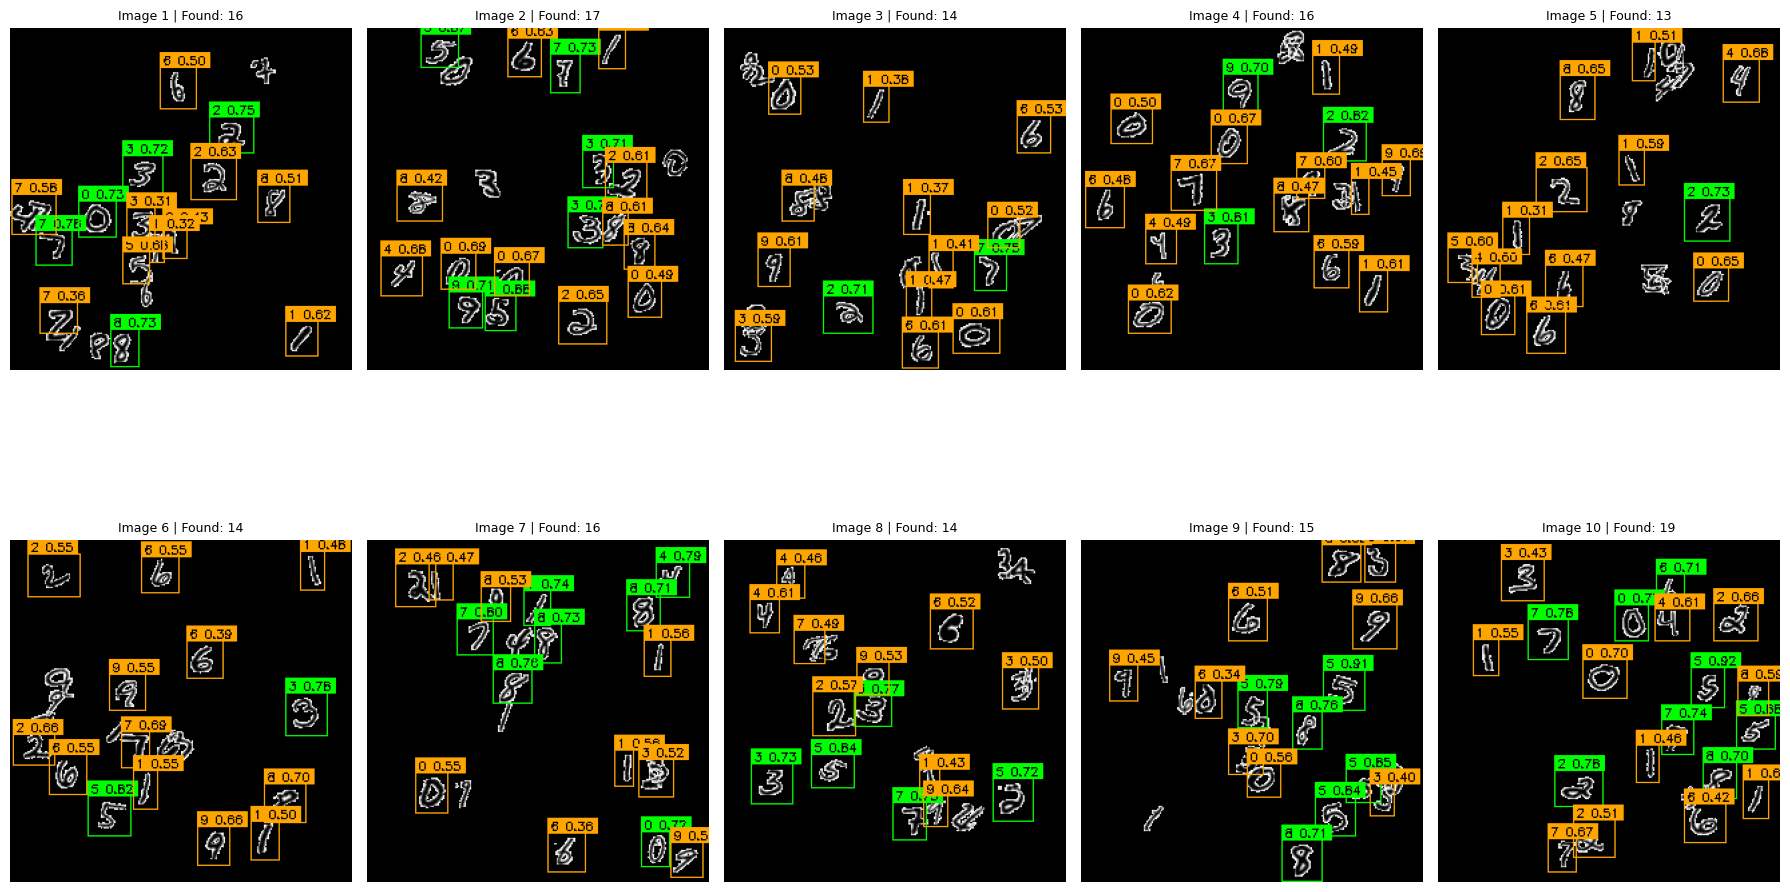

In [46]:
%matplotlib inline

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from collections import Counter
import os
import random

model = YOLO("../runs/detect/yolo_mnist_custom_train-5/weights/best.pt")

test_dir = "../data/mnist_yolo_training/test"

def draw_detection(image_path, conf=0.25):
    results = model.predict(
        source=image_path,
        conf=conf,
        iou=0.45,
        imgsz=256,
        max_det=50,
        verbose=False
    )

    result = results[0]

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    detected_classes = []

    font_scale = 0.3
    thickness = 1
    pad = 2

    for box, cls, score in zip(result.boxes.xyxy, result.boxes.cls, result.boxes.conf):
        x1, y1, x2, y2 = map(int, box)

        class_name = model.names[int(cls)]
        if class_name == "10":
            class_name = "9"
        detected_classes.append(class_name)

        color = (0, 255, 0) if score > 0.7 else (255, 165, 0)
        label = f"{class_name} {float(score):.2f}"

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 1)

        (w, h), _ = cv2.getTextSize(
            label,
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            thickness
        )

        y_label = max(y1 - h - pad * 2, 0)

        cv2.rectangle(
            img,
            (x1, y_label),
            (x1 + w + pad * 2, y1),
            color,
            -1
        )

        cv2.putText(
            img,
            label,
            (x1 + pad, y1 - pad),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (0, 0, 0),
            thickness
        )

    return img, Counter(detected_classes)

# Get random 10 images
image_files = [
    os.path.join(test_dir, f)
    for f in os.listdir(test_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

random_images = random.sample(image_files, min(10, len(image_files)))

plt.figure(figsize=(18, 12))

for i, image_path in enumerate(random_images):
    img, class_counts = draw_detection(image_path, conf=0.30)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(
        f"Image {i+1} | Found: {sum(class_counts.values())}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()